### Data provenance and trust hierarchy

In this project, the data are intentionally split into two distinct groups based on **data provenance and trust level**.
The **planetary Kp index** (and associated geomagnetic indices) is treated as a **trusted reference dataset**, sourced directly from official geomagnetic observatories and distributed by GFZ/ISGI. It defines both the **time grid** and the **prediction target**, and is therefore handled independently.
https://kp.gfz.de/en/data

All other variables (solar wind and IMF parameters) are obtained from **merged upstream products** (e.g. OMNI), which may internally include reconstructed or cross-calibrated geomagnetic quantities (including Kp or related indices). These secondary representations are **not used** for target construction or persistence features, in order to avoid inconsistencies, hidden preprocessing assumptions, or inadvertent information leakage.
https://omniweb.gsfc.nasa.gov/form/dx1.html






## STEP 1 —  Freeze the time grid of kp and np

 This script loads the 3‑hourly Kp index from kp_ap.txt, builds a clean time‑grid dataframe with timestamp_utc and kp, and enforces data integrity (strictly increasing timestamps, no duplicates, and exact 3‑hour spacing). It
  then plots the full record using a daily mean to avoid overplotting, providing a quick visual sanity check over the entire available timeframe.

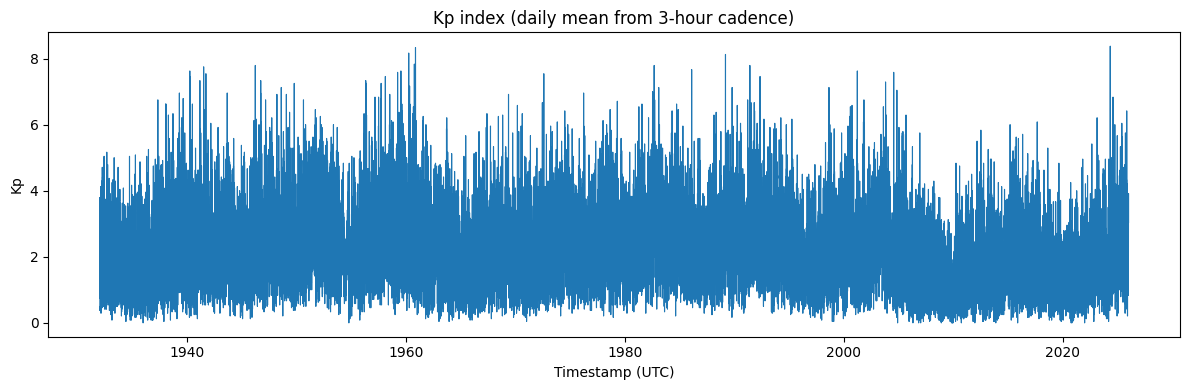

Kp rows: 274768
Date range: 1932-01-01 00:00:00+00:00 → 2026-01-12 21:00:00+00:00
Plot saved to: /media/nuopel/DATA/ProjectsAndTools/1_Projects/AI/Capstone_2/Codes_and_notebooks/../Data/processed/kp_3h_overview.png


In [4]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "../Data"
KP_FILE = DATA_DIR / "kp_ap.txt"
OUTPUT_DIR = DATA_DIR / "processed"

PLOT_PATH = OUTPUT_DIR / "kp_3h_overview.png"


def load_kp() -> pd.DataFrame:
    columns = [
        "year",
        "month",
        "day",
        "hour_start",
        "hour_mid",
        "days_start",
        "days_mid",
        "kp",
        "ap",
        "definitive_flag",
    ]
    df = pd.read_csv(
        KP_FILE,
        sep=r"\s+",
        header=None,
        names=columns,
        comment="#",
    )

    hour_float = df["hour_start"]
    hours = hour_float.astype(int)
    minutes = ((hour_float - hours) * 60).round().astype(int)

    df["timestamp_utc"] = pd.to_datetime(
        {
            "year": df["year"],
            "month": df["month"],
            "day": df["day"],
            "hour": hours,
            "minute": minutes,
        },
        utc=True,
    )

    kp_df = df[["timestamp_utc", "kp"]].copy()
    kp_df = kp_df.sort_values("timestamp_utc").reset_index(drop=True)
    return kp_df


def assert_time_grid(kp_df: pd.DataFrame) -> None:
    timestamps = kp_df["timestamp_utc"]
    assert timestamps.is_monotonic_increasing, "timestamp_utc is not strictly monotonic"
    assert timestamps.is_unique, "timestamp_utc has duplicates"

    deltas = timestamps.diff().dropna()
    expected = pd.Timedelta(hours=3)
    assert (deltas == expected).all(), "timestamp_utc spacing is not uniform 3 hours"


def plot_kp(kp_df: pd.DataFrame) -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    series = (
        kp_df.set_index("timestamp_utc")["kp"]
        .resample("1D")
        .mean()
        .dropna()
    )

    plt.figure(figsize=(12, 4))
    plt.plot(series.index, series.values, linewidth=0.8)
    plt.title("Kp index (daily mean from 3-hour cadence)")
    plt.xlabel("Timestamp (UTC)")
    plt.ylabel("Kp")
    plt.tight_layout()
    plt.savefig(PLOT_PATH, dpi=150)
    plt.show()


def main() -> None:
    kp_df = load_kp()
    assert_time_grid(kp_df)
    plot_kp(kp_df)

    print("Kp rows:", len(kp_df))
    print("Date range:", kp_df["timestamp_utc"].min(), "→", kp_df["timestamp_utc"].max())
    print("Plot saved to:", PLOT_PATH)


if __name__ == "__main__":
    main()


## STEP 2 — Resample OMNI → 3h (physics-aware)


This script loads hourly OMNI2 solar wind/IMF data, builds a UTC timestamp, and resamples it to the Kp 3‑hour grid using physics‑aware aggregations over right‑closed windows (t−3h, t] with a ≥70% coverage rule to avoid sparse
  windows. It produces a clean 3‑hour driver table (Bz min, By mean, |B| mean, speed/density/temperature means, plus OMNI’s Kp/ap for comparison), saves it to Data/processed/omni_3h.parquet, and plots the last two weeks for a
  quick sanity check of storm behavior.

  The Kp–OMNI merge is on the overlapping 3‑hour grid (starting in 1963). The grid itself is perfectly regular, but OMNI contains official missing‑data flags (e.g., 999.9 / 9999 / 9999999), which become NaNs after cleaning. If
  rows with any NaNs are dropped, the time grid develops gaps. To preserve a continuous timeline, the master file keeps NaNs and only restricts to the overlap period.

/tmp/ipykernel_42560/708739130.py:68: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled = series.resample("3H", label="right", closed="right")
/tmp/ipykernel_42560/708739130.py:68: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled = series.resample("3H", label="right", closed="right")
/tmp/ipykernel_42560/708739130.py:68: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled = series.resample("3H", label="right", closed="right")
/tmp/ipykernel_42560/708739130.py:68: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled = series.resample("3H", label="right", closed="right")
/tmp/ipykernel_42560/708739130.py:68: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled = series.resample("3H", label="right", c

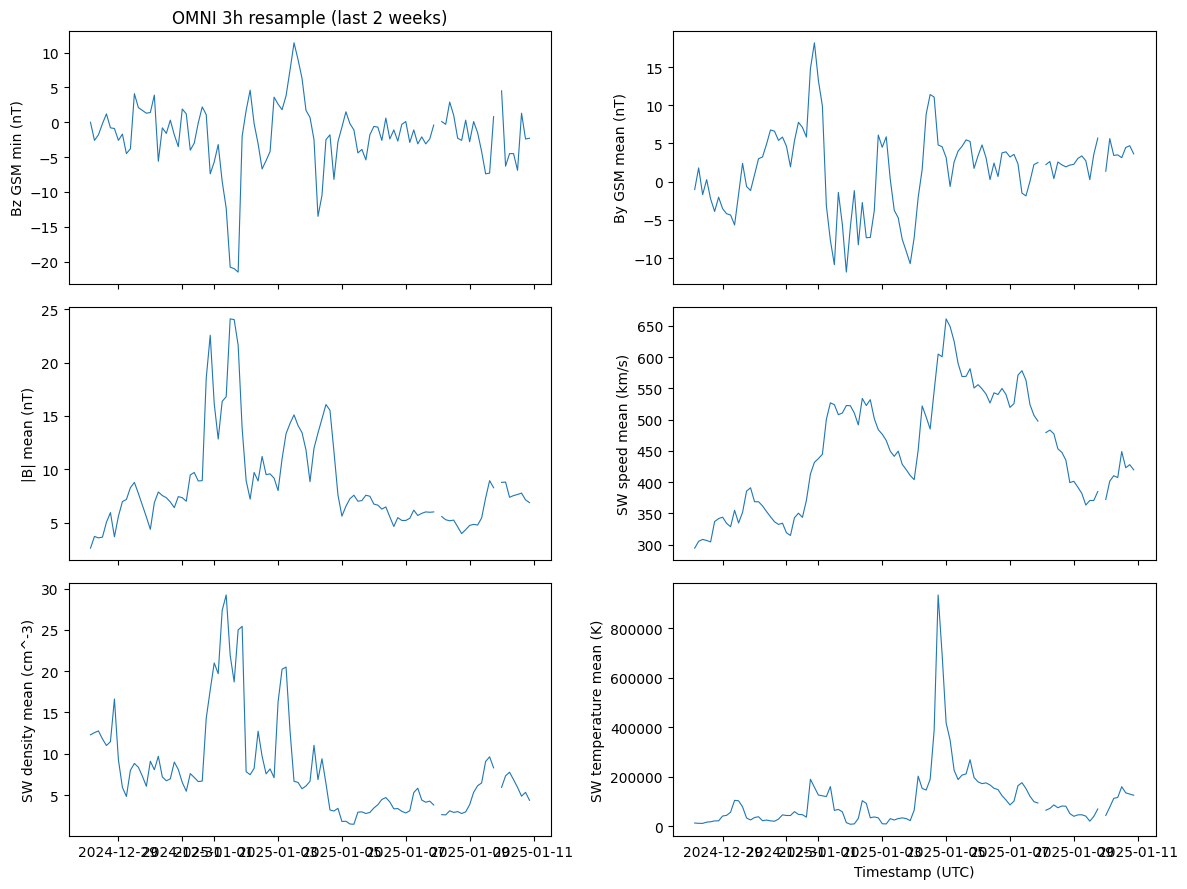

Saved: /media/nuopel/DATA/ProjectsAndTools/1_Projects/AI/Capstone_2/Codes_and_notebooks/../Data/processed/omni_3h.parquet
Date range: 1963-11-28 00:00:00+00:00 → 2025-01-11 00:00:00+00:00


In [8]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path

# Project root assumed to be the parent of the notebook directory

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "../Data"
OUTPUT_DIR = DATA_DIR / "processed"


OMNI_FILE = DATA_DIR / "omni2_data_2.lst"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PARQUET = OUTPUT_DIR / "omni_3h.parquet"
PLOT_PATH = OUTPUT_DIR / "omni_3h_overview.png"



def load_omni() -> pd.DataFrame:
    columns = [
        "year",
        "doy",
        "hour",
        "b_scalar",
        "by_gsm",
        "bz_gsm",
        "sw_temperature",
        "sw_density",
        "sw_speed",
        "kp_index",
        "ap_index",
    ]

    df = pd.read_csv(OMNI_FILE, sep=r"\s+", header=None, names=columns)

    timestamp = pd.to_datetime(
        df["year"].astype(str)
        + df["doy"].astype(int).astype(str).str.zfill(3)
        + df["hour"].astype(int).astype(str).str.zfill(2),
        format="%Y%j%H",
        utc=True,
    )
    df["timestamp_utc"] = timestamp

    missing_thresholds = {
        "b_scalar": 999.0,
        "by_gsm": 999.0,
        "bz_gsm": 999.0,
        "sw_temperature": 9_990_000.0,
        "sw_density": 999.0,
        "sw_speed": 9_999.0,
    }
    for column, threshold in missing_thresholds.items():
        df.loc[df[column] >= threshold, column] = np.nan

    return df.set_index("timestamp_utc").sort_index()


def resample_3h(series: pd.Series, agg: str) -> pd.Series:
    resampled = series.resample("3H", label="right", closed="right")
    aggregated = resampled.agg(agg)
    coverage = resampled.count() / 3.0
    aggregated[coverage < 0.7] = np.nan
    return aggregated


def build_omni_3h(df: pd.DataFrame) -> pd.DataFrame:
    agg_map = {
        "bz_gsm": "min",
        "by_gsm": "mean",
        "b_scalar": "mean",
        "sw_speed": "mean",
        "sw_density": "mean",
        "sw_temperature": "mean",
        "kp_index": "mean",
        "ap_index": "mean",
    }

    parts = {}
    for column, agg in agg_map.items():
        name = f"{column}_3h_{agg}"
        parts[name] = resample_3h(df[column], agg)

    omni_3h = pd.DataFrame(parts).reset_index()
    return omni_3h


def plot_overview(omni_3h: pd.DataFrame) -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    window = omni_3h.tail(14 * 8)

    fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
    axes = axes.ravel()

    series_map = [
        ("bz_gsm_3h_min", "Bz GSM min (nT)"),
        ("by_gsm_3h_mean", "By GSM mean (nT)"),
        ("b_scalar_3h_mean", "|B| mean (nT)"),
        ("sw_speed_3h_mean", "SW speed mean (km/s)"),
        ("sw_density_3h_mean", "SW density mean (cm^-3)"),
        ("sw_temperature_3h_mean", "SW temperature mean (K)"),
    ]

    for ax, (column, label) in zip(axes, series_map):
        ax.plot(window["timestamp_utc"], window[column], linewidth=0.8)
        ax.set_ylabel(label)

    axes[0].set_title("OMNI 3h resample (last 2 weeks)")
    axes[-1].set_xlabel("Timestamp (UTC)")

    plt.tight_layout()
    plt.savefig(PLOT_PATH, dpi=150)
    plt.show()


def main() -> None:
    df = load_omni()
    omni_3h = build_omni_3h(df)
    omni_3h['kp_index_3h_mean'] = omni_3h['kp_index_3h_mean']/10

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    # omni_3h.to_parquet(OUTPUT_PARQUET, index=False)
    omni_3h.to_parquet(OUTPUT_PARQUET, index=False, engine="fastparquet")
    plot_overview(omni_3h)
    print("Saved:", OUTPUT_PARQUET)
    print(
        "Date range:",
        omni_3h["timestamp_utc"].min(),
        "→",
        omni_3h["timestamp_utc"].max(),
    )


if __name__ == "__main__":
    main()


## STEP 3 — Align & merge
 This step aligns the definitive Kp “spine” with the physics‑aware OMNI 3‑hour table on timestamp_utc, drops any rows with missing OMNI drivers, and reports the resulting data loss to keep coverage transparent. The merged
  dataset is saved as Data/processed/master_3h.parquet as the single source of truth for downstream steps. A comparison plot is also generated to check OMNI Kp against GFZ Kp (for validation only), while OMNI Kp is excluded from
  the exported master file.


Rows before drop: 178601
Rows after drop: 115814
Data loss (%): 35.15
Saved: /media/nuopel/DATA/ProjectsAndTools/1_Projects/AI/Capstone_2/Codes_and_notebooks/../Data/processed/master_3h.parquet
Date range: 1965-07-29 06:00:00+00:00 → 2025-01-10 21:00:00+00:00
Kp comparison count: 115814
Kp correlation: 0.9079
Kp mean absolute diff: 0.4366
Kp max absolute diff: 3.767


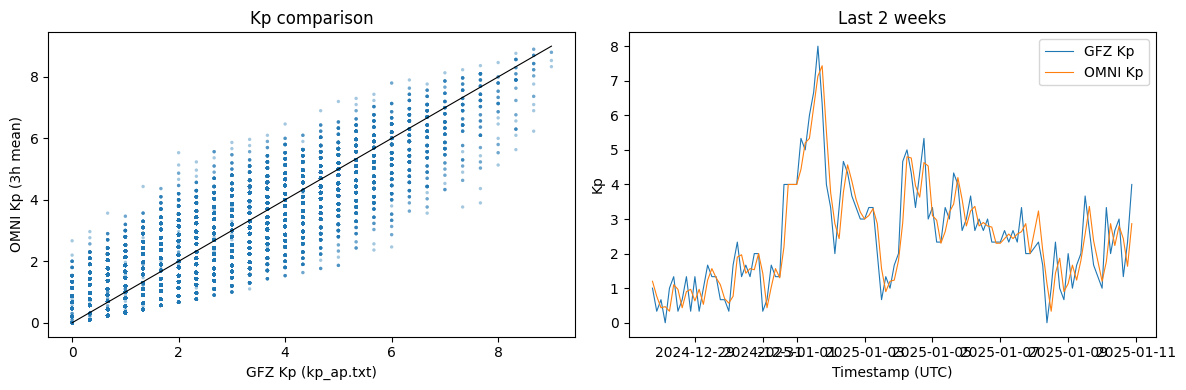

In [14]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "../Data"
OUTPUT_DIR = DATA_DIR / "processed"



OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PARQUET = OUTPUT_DIR / "omni_3h.parquet"

KP_FILE = DATA_DIR / "kp_ap.txt"
OMNI_3H_FILE = DATA_DIR / "processed" / "omni_3h.parquet"
OUTPUT_DIR = DATA_DIR / "processed"
MASTER_FILE = OUTPUT_DIR / "master_3h.parquet"
PLOT_PATH = OUTPUT_DIR / "kp_comparison.png"


def load_kp_spine() -> pd.DataFrame:
    columns = [
        "year",
        "month",
        "day",
        "hour_start",
        "hour_mid",
        "days_start",
        "days_mid",
        "kp",
        "ap",
        "definitive_flag",
    ]
    df = pd.read_csv(KP_FILE, sep=r"\s+", header=None, names=columns, comment="#")

    hour_float = df["hour_start"]
    hours = hour_float.astype(int)
    minutes = ((hour_float - hours) * 60).round().astype(int)

    df["timestamp_utc"] = pd.to_datetime(
        {
            "year": df["year"],
            "month": df["month"],
            "day": df["day"],
            "hour": hours,
            "minute": minutes,
        },
        utc=True,
    )

    kp_df = df[["timestamp_utc", "kp"]].copy()
    kp_df = kp_df.sort_values("timestamp_utc").reset_index(drop=True)
    return kp_df


def load_omni_3h() -> pd.DataFrame:
    omni = pd.read_parquet(OMNI_3H_FILE, engine="fastparquet")
    omni = omni.drop(columns=["ap_index_3h_mean"], errors="ignore")
    return omni


def compare_kp(master: pd.DataFrame) -> None:
    compare = master.dropna(subset=["kp", "kp_index_3h_mean"])
    if compare.empty:
        print("No overlapping Kp values to compare.")
        return

    diff = compare["kp"] - compare["kp_index_3h_mean"]
    corr = compare["kp"].corr(compare["kp_index_3h_mean"])
    print("Kp comparison count:", len(compare))
    print("Kp correlation:", round(corr, 4))
    print("Kp mean absolute diff:", round(diff.abs().mean(), 4))
    print("Kp max absolute diff:", round(diff.abs().max(), 4))

    window = compare.tail(14 * 8)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(
        compare["kp"],
        compare["kp_index_3h_mean"],
        s=6,
        alpha=0.4,
        edgecolors="none",
    )
    axes[0].plot([0, 9], [0, 9], color="black", linewidth=0.8)
    axes[0].set_xlabel("GFZ Kp (kp_ap.txt)")
    axes[0].set_ylabel("OMNI Kp (3h mean)")
    axes[0].set_title("Kp comparison")

    axes[1].plot(window["timestamp_utc"], window["kp"], label="GFZ Kp", linewidth=0.8)
    axes[1].plot(
        window["timestamp_utc"],
        window["kp_index_3h_mean"],
        label="OMNI Kp",
        linewidth=0.8,
    )
    axes[1].set_xlabel("Timestamp (UTC)")
    axes[1].set_ylabel("Kp")
    axes[1].legend(loc="upper right")
    axes[1].set_title("Last 2 weeks")

    plt.tight_layout()
    plt.savefig(PLOT_PATH, dpi=150)
    plt.show()



def report_time_gaps(df: pd.DataFrame, label: str, max_rows: int = 10) -> None:
    timestamps = df["timestamp_utc"]
    deltas = timestamps.diff().dropna()
    expected = pd.Timedelta(hours=3)
    gaps = deltas[deltas != expected]

    print(f"{label} gaps: {len(gaps)}")
    if gaps.empty:
        return

    gap_rows = gaps.head(max_rows)
    report = pd.DataFrame(
        {
            "prev_timestamp": timestamps.shift(1).loc[gap_rows.index],
            "next_timestamp": timestamps.loc[gap_rows.index],
            "delta": gap_rows.values,
        }
    )
    print(report)



if __name__ == "__main__":
    kp_df = load_kp_spine()
    omni_3h = load_omni_3h()
    master = kp_df.merge(omni_3h, on="timestamp_utc", how="inner")
    assert_time_grid(master)
    report_time_gaps(master, "Merged (pre-drop)")

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    master.to_parquet(MASTER_FILE, index=False)

    required_cols = [
        col
        for col in omni_3h.columns
        if col not in {"timestamp_utc", "sw_temperature_3h_mean"}
    ]
    missing_any = master[required_cols].isna().any(axis=1)
    print("Rows with any OMNI missing:", int(missing_any.sum()))
    if missing_any.any():
        print("First missing timestamps:")
        print(master.loc[missing_any, "timestamp_utc"].head(10).to_string(index=False))

    print("Rows (overlap):", len(master))

    print("Saved:", MASTER_FILE)
    print(
        "Date range:",
        master["timestamp_utc"].min(),
        "→",
        master["timestamp_utc"].max(),
    )

    compare_kp(master)




### Why GFZ Kp and OMNI Kp differ

Although both GFZ Kp and OMNI Kp describe the same geomagnetic activity, small but systematic differences are expected.

**(1)** GFZ Kp is the official planetary index, computed from multiple ground-based magnetometers using discrete classification rules, whereas OMNI Kp is a reconstructed proxy included in a merged space-weather product.

**(2)** GFZ Kp is intrinsically discrete (fixed thirds), while OMNI Kp behaves as a continuous, averaged quantity, leading to spread around each GFZ value.

**(3)** The two products are not perfectly aligned in time: OMNI Kp may involve smoothing or slight shifts to match solar-wind timing, which becomes visible during rapid storm onsets or recoveries.

**(4)** Despite these differences, both indices respond to the same physical drivers, explaining the high correlation, while event-level discrepancies remain unavoidable.


In the end OMNI kp is drop in favor of the GFZ which is likely more accurate


In [20]:
master.columns


Index(['timestamp_utc', 'kp', 'bz_gsm_3h_min', 'by_gsm_3h_mean',
       'b_scalar_3h_mean', 'sw_speed_3h_mean', 'sw_density_3h_mean',
       'sw_temperature_3h_mean'],
      dtype='object')

In [21]:
master.head()

,timestamp_utc,kp,bz_gsm_3h_min,by_gsm_3h_mean,b_scalar_3h_mean,sw_speed_3h_mean,sw_density_3h_mean,sw_temperature_3h_mean
4874,1965-07-29 06:00:00+00:00,3.333,-1.8,-2.600000,5.300000,584.666667,5.300000,220399.666667
4875,1965-07-29 09:00:00+00:00,2.000,0.8,-0.866667,4.833333,595.666667,4.800000,237674.666667
4878,1965-07-29 18:00:00+00:00,3.000,-4.9,-1.100000,6.033333,593.666667,3.900000,241052.666667
4879,1965-07-29 21:00:00+00:00,1.333,-1.9,-1.866667,5.666667,585.333333,4.200000,245124.000000
4889,1965-07-31 03:00:00+00:00,0.667,0.6,-5.266667,6.233333,492.000000,3.466667,114789.000000
